<a href="https://colab.research.google.com/github/mrms-dev/Telecom-churn-analysis-v2/blob/main/Telecom_Churn_Predictive_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Início fase 2 - Importação de todas as Bibliotecas (DEPENDÊNCIAS DO PROJETO)

## Passo 1

In [1]:
# Manipulação e Análise de Dados
import pandas as pd
import numpy as np

# Visualização de Dados
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e Transformação
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Modelagem Preditiva (Algoritmos)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Avaliação e Validação de Modelos
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Configurações de exibição do Pandas
pd.set_option('display.max_columns', None)

print("Bibliotecas importadas com sucesso para a Fase 2!")

Bibliotecas importadas com sucesso para a Fase 2!


## Passo 2

## Carregamento e Classificação das Variáveis

In [6]:
# Carregamento da base de dados vinda do repositório
df = pd.read_csv('telecomx_churn_limpo_atualizado.csv')

# Descarte da coluna customerID (é apenas um identificador, não ajuda na predição)
df_model = df.drop(columns=['customerID'])

# Identificação e separação dos tipos de dados
# O modelo precisa saber o que é texto (object) e o que é número
colunas_categoricas = df_model.select_dtypes(include=['object']).columns
colunas_numericas = df_model.select_dtypes(exclude=['object']).columns

# Exibição para conferência
print(f"Variáveis Categóricas (Texto): {list(colunas_categoricas)}")
print(f" Variáveis Numéricas (Números): {list(colunas_numericas)}")
print("-" * 30)
print(f"Formato da base: {df_model.shape[0]} linhas e {df_model.shape[1]} colunas.")

Variáveis Categóricas (Texto): ['Churn', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
 Variáveis Numéricas (Números): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
------------------------------
Formato da base: 7043 linhas e 20 colunas.


## Passo 3

## Codificação (Encoding).

In [7]:
# Aplicando a transformação de texto para número em todas as colunas categóricas
le = LabelEncoder()

for col in colunas_categoricas:
    df_model[col] = le.fit_transform(df_model[col])

# Exibindo as primeiras linhas para conferência técnica
print("Base de dados codificada com sucesso.")
print(df_model.head())

Base de dados codificada com sucesso.
   Churn  gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0      1       0              0        1           1       9             1   
1      1       1              0        0           0       9             1   
2      0       1              0        0           0       4             1   
3      0       1              1        1           0      13             1   
4      0       0              1        1           0       3             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              0                0               0             2   
1              2                0               0             0   
2              0                1               0             0   
3              0                1               0             2   
4              0                1               0             0   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0             

## Passo 4

## Correlação de Variáveis

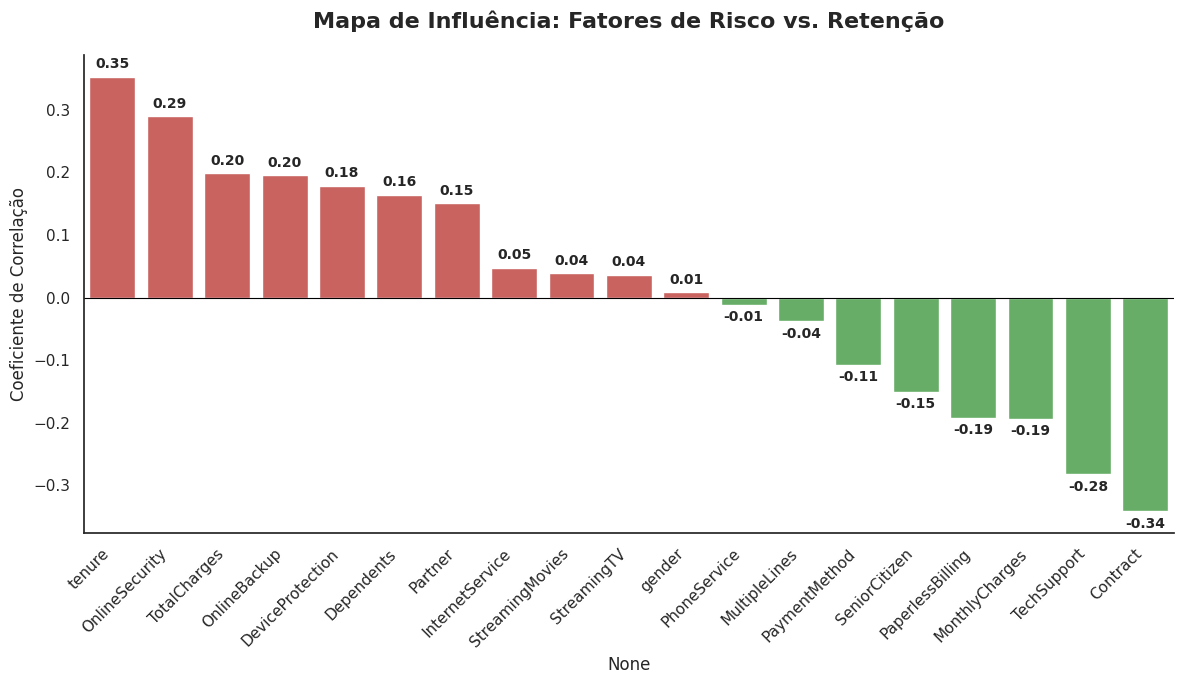

In [21]:
# Calculando a correlação
correlacao = df_model.corr()['Churn'].sort_values(ascending=False).drop('Churn')

# 2. Configurando o visual
plt.figure(figsize=(12, 7))
sns.set_style("white")

# Criando um mapa de cores: Vermelho para correlação positiva (alerta) e Verde para negativa (retenção)
colors = ['#d9534f' if x > 0 else '#5cb85c' for x in correlacao.values]

# Criando o gráfico
ax = sns.barplot(x=correlacao.index, y=correlacao.values, palette=colors, hue=correlacao.index, legend=False)

# Refinando a estética
plt.title('Mapa de Influência: Fatores de Risco vs. Retenção', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Coeficiente de Correlação', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=0.8) # Linha de base zero

# Adicionando os valores sobre as barras para precisão total
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9 if p.get_height() > 0 else -9),
                textcoords = 'offset points',
                fontsize=10, fontweight='bold')

sns.despine() # Remove as bordas superior e direita
plt.tight_layout()
plt.show()

## Passo 5

## Divisão entre Treino e Teste

In [9]:
# Separando as variáveis preditivas (X) da variável alvo (y)
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# Dividindo os dados em Treino (70%) e Teste (30%)
# Definimos o random_state para garantir que o resultado seja replicável
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Conferindo o tamanho das divisões
print(f"Dados de Treino: {X_train.shape[0]} amostras")
print(f"Dados de Teste: {X_test.shape[0]} amostras")

Dados de Treino: 4930 amostras
Dados de Teste: 2113 amostras


## Passo 6

## Modelo 1 - Regressão Logística

In [11]:
# Ajustando a escala dos dados (Normalização)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Treinando novamente a Regressão Logística com dados escalados
modelo_logistico = LogisticRegression()
modelo_logistico.fit(X_train_scaled, y_train)

# Gerando novas previsões
previsoes_logistica = modelo_logistico.predict(X_test_scaled)

print("Modelo de Regressão Logística treinado com sucesso (sem avisos de convergência).")

Modelo de Regressão Logística treinado com sucesso (sem avisos de convergência).


## Passo 7

## Modelo 2 - Random Forest (Floresta Aleatória)

In [12]:
# Instanciando o modelo Random Forest
# Usamos o random_state para que o resultado seja sempre o mesmo ao rodar
modelo_forest = RandomForestClassifier(random_state=42)

# Treinando o modelo (usando X_train e y_train originais)
modelo_forest.fit(X_train, y_train)

# Realizando as previsões para avaliação posterior
previsoes_forest = modelo_forest.predict(X_test)

print("Modelo Random Forest treinado com sucesso.")

Modelo Random Forest treinado com sucesso.


## Passo 8

## Avaliação dos Modelos

In [13]:
# Avaliação da Regressão Logística
print("=== AVALIAÇÃO: REGRESSÃO LOGÍSTICA ===")
print(classification_report(y_test, previsoes_logistica))
print("Matriz de Confusão:")
print(confusion_matrix(y_test, previsoes_logistica))

print("\n" + "="*40 + "\n")

# Avaliação do Random Forest
print("=== AVALIAÇÃO: RANDOM FOREST ===")
print(classification_report(y_test, previsoes_forest))
print("Matriz de Confusão:")
print(confusion_matrix(y_test, previsoes_forest))

=== AVALIAÇÃO: REGRESSÃO LOGÍSTICA ===
              precision    recall  f1-score   support

           0       0.66      0.55      0.60       551
           1       0.85      0.90      0.87      1562

    accuracy                           0.81      2113
   macro avg       0.75      0.72      0.74      2113
weighted avg       0.80      0.81      0.80      2113

Matriz de Confusão:
[[ 302  249]
 [ 158 1404]]


=== AVALIAÇÃO: RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.63      0.48      0.54       551
           1       0.83      0.90      0.86      1562

    accuracy                           0.79      2113
   macro avg       0.73      0.69      0.70      2113
weighted avg       0.78      0.79      0.78      2113

Matriz de Confusão:
[[ 262  289]
 [ 155 1407]]


## Passo 9

## Importância das Variáveis

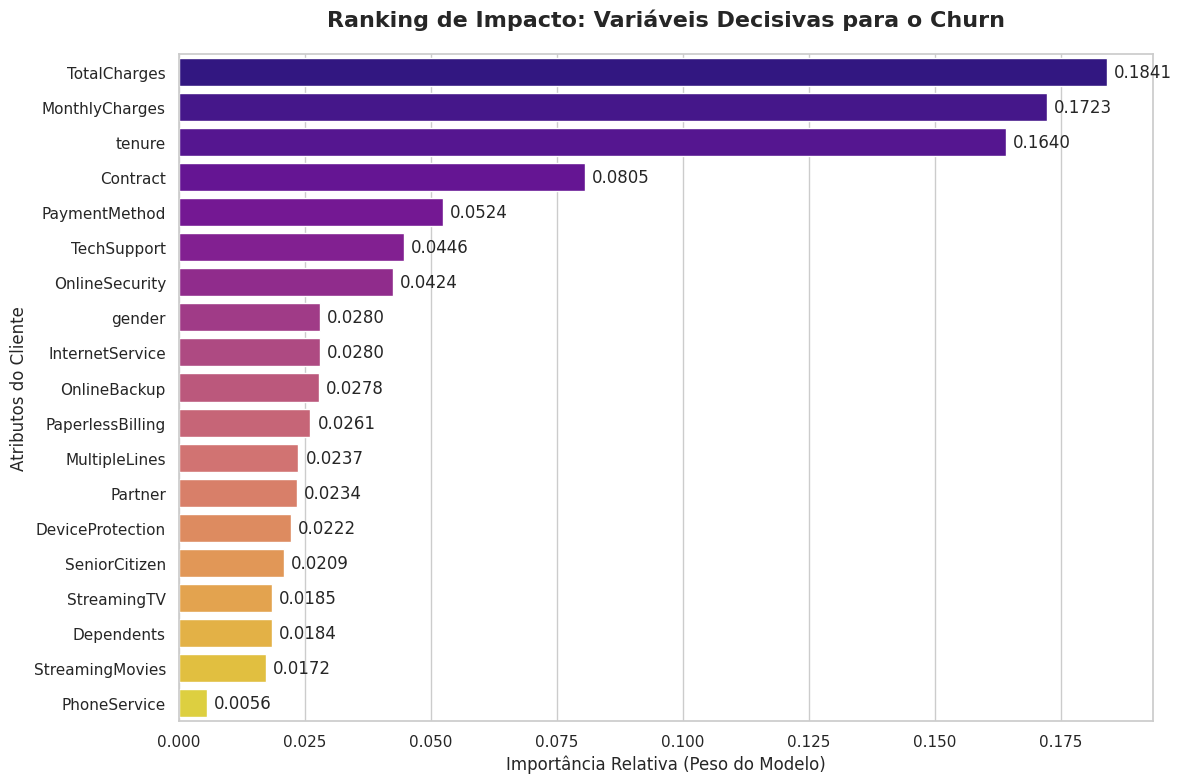


TABELA DE IMPORTÂNCIA DAS VARIÁVEIS (REFERÊNCIA)
        Variável  Importância
    TotalCharges     0.184146
  MonthlyCharges     0.172296
          tenure     0.164027
        Contract     0.080548
   PaymentMethod     0.052399
     TechSupport     0.044642
  OnlineSecurity     0.042388
          gender     0.027985
 InternetService     0.027960
    OnlineBackup     0.027757
PaperlessBilling     0.026073
   MultipleLines     0.023690
         Partner     0.023360
DeviceProtection     0.022236
   SeniorCitizen     0.020854
     StreamingTV     0.018473
      Dependents     0.018391
 StreamingMovies     0.017218
    PhoneService     0.005555


In [20]:
# Configuração visual do gráfico
sns.set_theme(style="whitegrid") # Fundo branco com linhas de grade suaves
plt.figure(figsize=(12, 8))

# Gerando o gráfico com paleta harmônica e com degradê suave
# A paleta 'plasma' é vibrante e não chega ao amarelo esbranquiçado, mantendo o contraste.
grafico = sns.barplot(
    x='Importância',
    y='Variável',
    data=df_importancia,
    palette='plasma', # Paleta mais suave e harmônica
    hue='Variável',
    legend=False
)

# Estilização de títulos e rótulos profissionais
plt.title('Ranking de Impacto: Variáveis Decisivas para o Churn', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Importância Relativa (Peso do Modelo)', fontsize=12)
plt.ylabel('Atributos do Cliente', fontsize=12)

# Adiciona os valores nas barras para precisão
for i in grafico.containers:
    grafico.bar_label(i, fmt='%.4f', padding=5)

plt.tight_layout()
plt.show()

# Exibição da Tabela para Cópia (Mantendo nossa precisão analítica)
print("\n" + "="*40)
print("TABELA DE IMPORTÂNCIA DAS VARIÁVEIS (REFERÊNCIA)")
print("="*40)
print(df_importancia.to_string(index=False))
print("="*40)